In [1]:
import pandas as pd
print(pd.__version__)

3.0.6


In [2]:
import pandas as pd

orders = pd.read_csv(
    "../raw/orders.csv",
    dtype={
        "order_id": "int32", "user_id": "int32", "eval_set": "category",
        "order_number": "int16", "order_dow": "int8",
        "order_hour_of_day": "int8", "days_since_prior_order": "float32",
    },
)
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [3]:
nulls = orders[orders["days_since_prior_order"].isna()]
print("Total nulls:", len(nulls))
print(nulls["order_number"].value_counts())

Total nulls: 206209
order_number
1    206209
Name: count, dtype: int64


In [4]:
orders["is_first_order"] = orders["order_number"] == 1

print(orders["is_first_order"].sum())
print("Avg days between orders:", orders["days_since_prior_order"].mean())

206209
Avg days between orders: 11.114836


<Axes: title={'center': 'Orders by hour of day'}, xlabel='order_hour_of_day'>

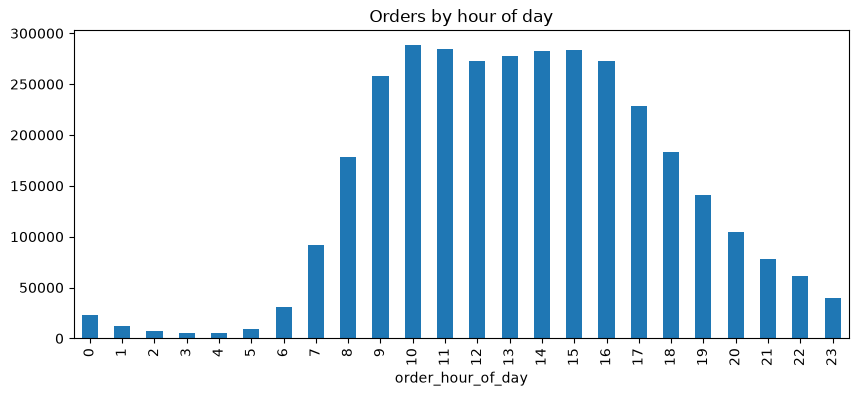

In [5]:
hourly = orders["order_hour_of_day"].value_counts().sort_index()
hourly.plot(kind="bar", figsize=(10, 4), title="Orders by hour of day")

<Axes: title={'center': 'Orders by day of week'}, xlabel='order_dow'>

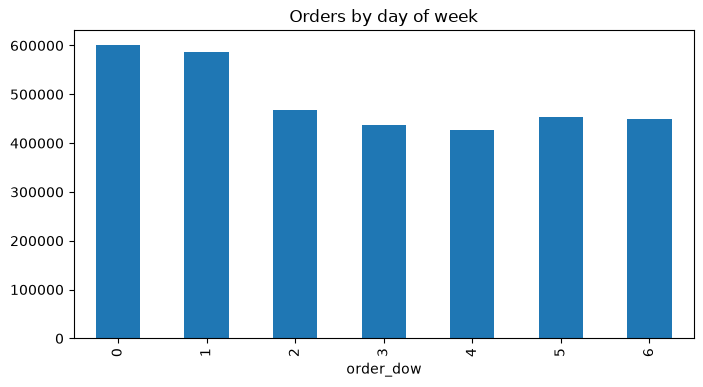

In [6]:
daily = orders["order_dow"].value_counts().sort_index()
daily.plot(kind="bar", figsize=(8, 4), title="Orders by day of week")